In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv


In [10]:
data= pd.read_csv('/kaggle/input/datasets/vjchoudhary7/customer-segmentation-tutorial-in-python/Mall_Customers.csv')
data.drop(['CustomerID'],axis=1)


,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40
...,...,...,...,...
195,Female,35,120,79
196,Female,45,126,28
197,Male,32,126,74
198,Male,32,137,18


In [13]:
data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,1,19,15,39
1,2,1,21,15,81
2,3,0,20,16,6
3,4,0,23,16,77
4,5,0,31,17,40


In [26]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   CustomerID              200 non-null    int64
 1   Gender                  200 non-null    int64
 2   Age                     200 non-null    int64
 3   Annual Income (k$)      200 non-null    int64
 4   Spending Score (1-100)  200 non-null    int64
dtypes: int64(5)
memory usage: 7.9 KB


In [11]:
from sklearn.preprocessing import LabelEncoder
le= LabelEncoder()
data['Gender']=le.fit_transform(data['Gender'])

In [19]:
from sklearn.cluster import KMeans
#dist=[]
    #for i in range(2,20):
model = KMeans(n_clusters=7,max_iter=1000)
model.fit(data)
    #dist.append(model.inertia_) 


KMeans(max_iter=1000, n_clusters=7)

In [15]:
dist

[387065.71377137717,
 271765.80974264705,
 195418.68669871797,
 166998.12384862357,
 137602.12877471454,
 113614.26231070099,
 94287.12334017927,
 86402.69765450066,
 72382.95733046194,
 64417.424745196324,
 61433.428605166744,
 60515.85098580074,
 55637.071241830046,
 52196.58946272184,
 47590.13374860432,
 44044.71293167616,
 43001.701739926735,
 42460.64675324675]

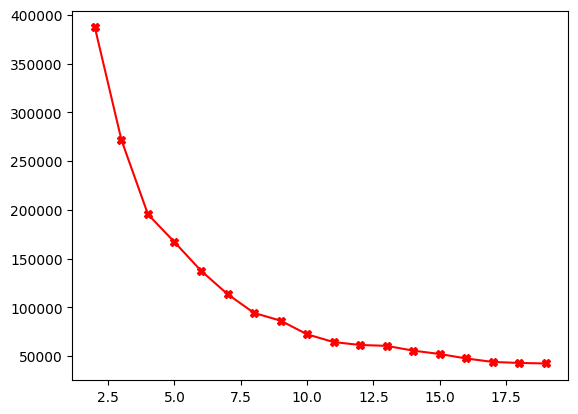

In [57]:
plt.plot(range(2,20),dist, marker='X', color="r")
plt.show()

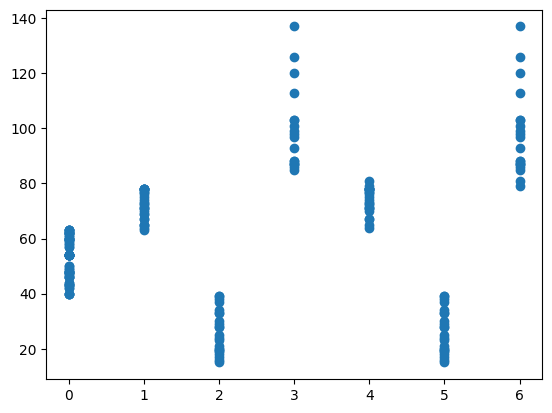

In [20]:
plt.scatter(model.predict(data),data['Annual Income (k$)'])
plt.show()

In [39]:
c= model.predict(data)
c=pd.DataFrame(c,columns=["classs"])
new_data = pd.concat([data,c],axis=1)
new_data.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),classs
0,1,1,19,15,39,5
1,2,1,21,15,81,2
2,3,0,20,16,6,5
3,4,0,23,16,77,2
4,5,0,31,17,40,5


In [37]:
new_data.corr()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),class
CustomerID,1.000000,0.057400,-0.026763,0.977548,0.013835,0.255982
Gender,0.057400,1.000000,0.060867,0.056410,-0.058109,-0.011892
Age,-0.026763,0.060867,1.000000,-0.012398,-0.327227,-0.099406
Annual Income (k$),0.977548,0.056410,-0.012398,1.000000,0.009903,0.238420
Spending Score (1-100),0.013835,-0.058109,-0.327227,0.009903,1.000000,-0.181026
class,0.255982,-0.011892,-0.099406,0.238420,-0.181026,1.000000


# now we can do it in classification as supervised

In [46]:
train_data= new_data.loc[:180, :]
x= train_data.drop(["classs"], axis=1)
y= train_data["classs"]

test_data= new_data.loc[180:, :]
x2= test_data.drop(["classs"], axis=1)
y2= test_data["classs"]

In [43]:
print(c.columns.tolist())

['classs']


In [42]:
print('classs' in c.columns)

True


In [48]:
from sklearn.linear_model import LogisticRegression
model2= LogisticRegression(max_iter=5300,tol=0.001)
model2.fit(x,y)

LogisticRegression(max_iter=5300, tol=0.001)

In [50]:
model2.score(x,y)

1.0

In [51]:
model2.score(x2,y2)

0.85